<a href="https://colab.research.google.com/github/ravirajchopade800-cloud/Superstore-sales-profit-analysis-ml/blob/main/Superstore_analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
df = pd.read_csv('/content/SampleSuperstore.csv')
df.head()

,Ship Mode,Segment,Country,City,State,Postal Code,Region,Category,Sub-Category,Sales,Quantity,Discount,Profit
0,Second Class,Consumer,United States,Henderson,Kentucky,42420,South,Furniture,Bookcases,261.9600,2,0.00,41.9136
1,Second Class,Consumer,United States,Henderson,Kentucky,42420,South,Furniture,Chairs,731.9400,3,0.00,219.5820
2,Second Class,Corporate,United States,Los Angeles,California,90036,West,Office Supplies,Labels,14.6200,2,0.00,6.8714
3,Standard Class,Consumer,United States,Fort Lauderdale,Florida,33311,South,Furniture,Tables,957.5775,5,0.45,-383.0310
4,Standard Class,Consumer,United States,Fort Lauderdale,Florida,33311,South,Office Supplies,Storage,22.3680,2,0.20,2.5164


In [ ]:
df.columns = df.columns.str.strip()

In [ ]:
df.columns = df.columns.str.strip()

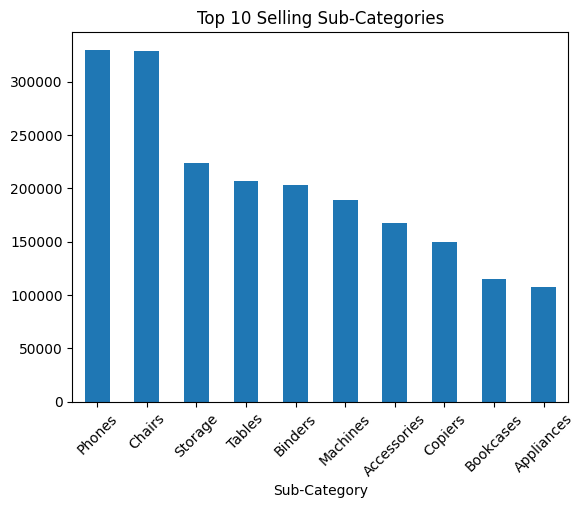

In [ ]:
top_products = df.groupby('Sub-Category')['Sales'].sum().sort_values(ascending=False).head(10)

import matplotlib.pyplot as plt

plt.figure()
top_products.plot(kind='bar')
plt.title('Top 10 Selling Sub-Categories')
plt.xticks(rotation=45)
plt.show()

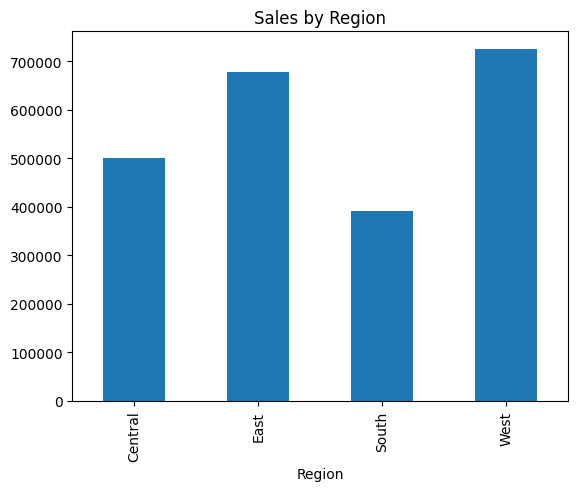

In [ ]:
region_sales = df.groupby('Region')['Sales'].sum()

region_sales.plot(kind='bar')
plt.title('Sales by Region')
plt.show()

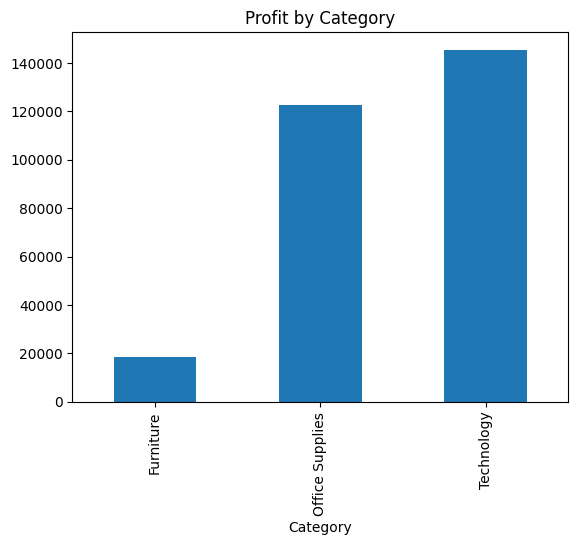

In [ ]:
profit_category = df.groupby('Category')['Profit'].sum()

profit_category.plot(kind='bar')
plt.title('Profit by Category')
plt.show()

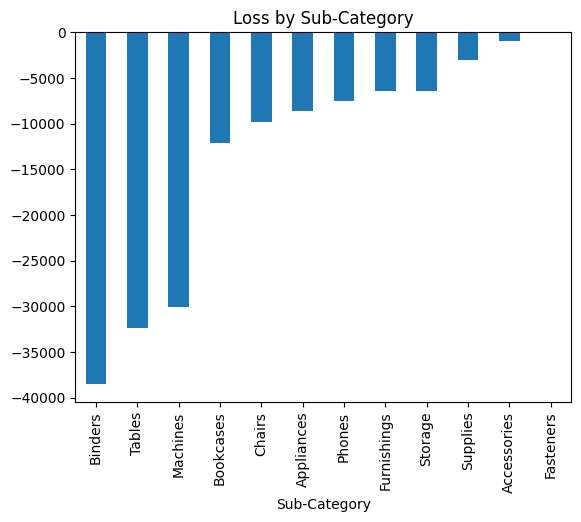

In [ ]:
loss_products = df[df['Profit'] < 0]

loss_products.groupby('Sub-Category')['Profit'].sum().sort_values().plot(kind='bar')

plt.title('Loss by Sub-Category')
plt.show()

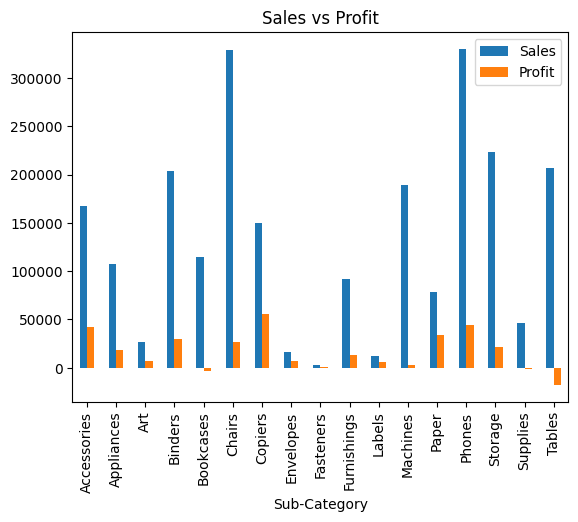

In [ ]:
sales_profit = df.groupby('Sub-Category')[['Sales','Profit']].sum()

sales_profit.plot(kind='bar')
plt.title('Sales vs Profit')
plt.show()

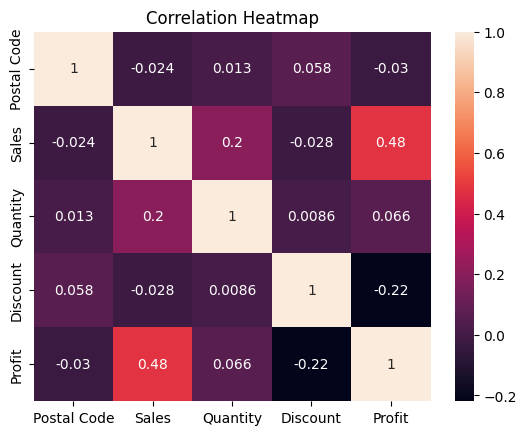

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.heatmap(df.corr(numeric_only=True), annot=True)
plt.title("Correlation Heatmap")
plt.show()

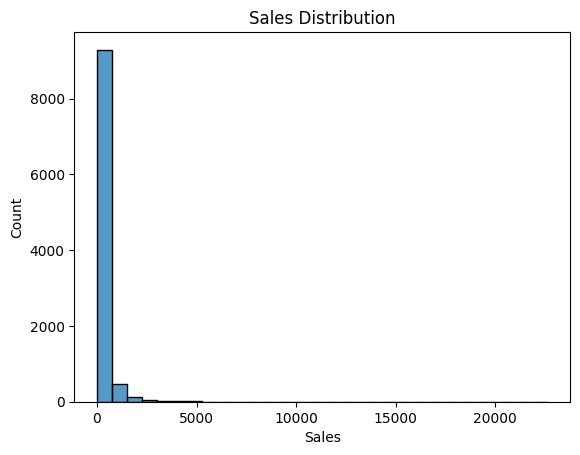

In [ ]:
sns.histplot(df['Sales'], bins=30)
plt.title("Sales Distribution")
plt.show()

<Axes: xlabel='Sales', ylabel='Count'>

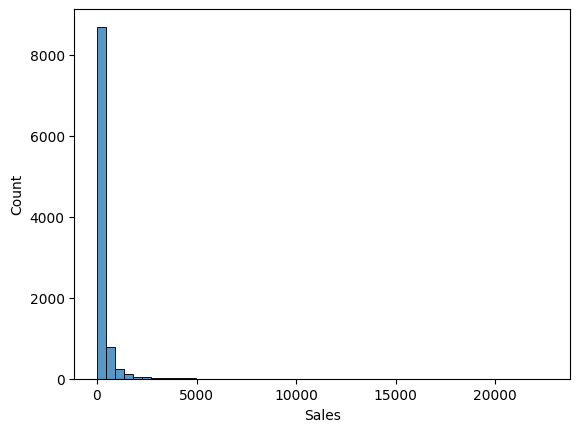

In [ ]:
sns.histplot(df['Sales'], bins=50)

<Axes: xlabel='Sales', ylabel='Count'>

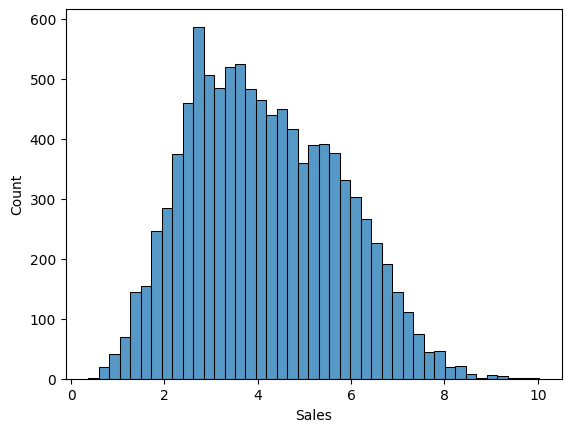

In [ ]:
import numpy as np
sns.histplot(np.log1p(df['Sales']))

<Axes: xlabel='Sales', ylabel='Count'>

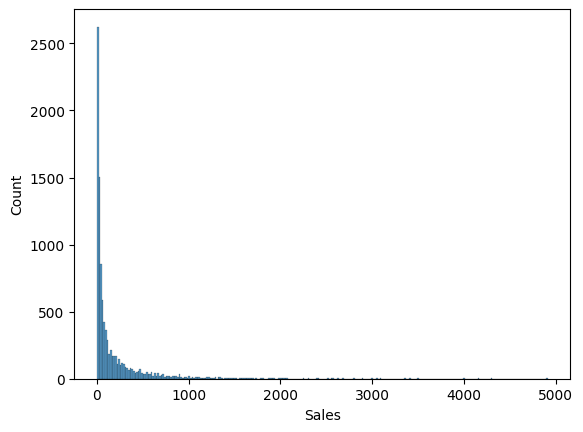

In [ ]:
sns.histplot(df[df['Sales'] < 5000]['Sales'])

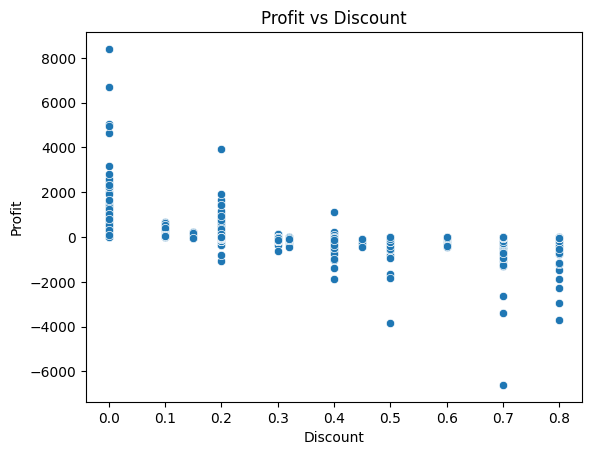

In [ ]:
sns.scatterplot(x='Discount', y='Profit', data=df)
plt.title("Profit vs Discount")
plt.show()

In [ ]:
df['Profit_Margin'] = df['Profit'] / df['Sales']

In [ ]:
from sklearn.model_selection import train_test_split

In [ ]:
from sklearn.ensemble import RandomForestRegressor

X = df[['Sales', 'Quantity', 'Discount', 'Profit_Margin']]
y = df['Profit']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

model = RandomForestRegressor(n_estimators=200, random_state=42)
model.fit(X_train, y_train)

predictions = model.predict(X_test)

In [ ]:
from sklearn.metrics import r2_score

print("Accuracy:", r2_score(y_test, predictions))

Accuracy: 0.9751005347244527
